<div class="usecase-title">SDNET2018 Data Exploration for Crack Detection</div>

<div class="usecase-authors"><b>Authored by: </b>Ishika</div>
<div class="usecase-duration"><b>Duration:</b> 360 minutes</div>

<div class="usecase-level-skill">
    <div class="usecase-level"><b>Level: </b>Intermediate</div>
    <div class="usecase-skill"><b>Pre-requisite Skills: </b>Python, OpenCV, computer vision, data exploration, Jupyter notebooks</div>
</div>

## Objective

Explore SDNET2018 concrete crack images, quantify class balance, profile pixel-intensity patterns, prepare stratified train/validation/test manifests, create balanced training options, and preview augmentation choices for downstream crack-detection experiments.

## Analysis Questions

- Are there missing, unreadable, duplicate, or visually unusual images that should be reviewed before modelling?
- How many cracked and uncracked images are available across deck, pavement, and wall surfaces?
- Do the surface/subclass folders create class imbalance that needs to be handled before modelling?
- Do grayscale intensity and texture proxies differ by crack status or surface type?
- Which split and balancing outputs should downstream training notebooks consume?
- Which dataset metadata and artifacts should be tracked in MLflow for reproducibility?

## Method

- Resolve the dataset from the approved API v2.1 source and cache it locally for repeatable runs.
- Build an image-level manifest from the SDNET2018 folder structure.
- Audit file quality, exact duplicate hashes, image geometry, and outlier examples.
- Summarise dataset size, geometry, class balance, surface crack rates, pixel-intensity statistics, and texture/edge features.
- Create stratified train/validation/test manifests and balanced training alternatives.
- Track the dataset profile, quality metrics, split metrics, manifests, and plots with MLflow.
- Preview mild image augmentations that preserve crack structure.

## Outputs

- Manifest CSV files under `artifacts/manifests/`.
- Class balance, surface crack-rate, pixel statistics, texture/edge, outlier, sample grid, balancing, and augmentation plots under `artifacts/plots/`.
- Dataset tracking metadata and artifacts in MLflow under `artifacts/mlruns` by default.
- Reusable split and balancing dataframes for the later classification and segmentation notebooks.

## Dataset Access

The dataset is resolved through an API v2.1 archive endpoint configured with `SDNET2018_API_V21_URL`. The downloaded archive is cached under `dataset/` so the notebook can be rerun without repeated network transfer.


## Imports And Configuration

These imports cover data discovery, plotting, balancing, and Albumentations-based augmentation previews.


In [1]:
from __future__ import annotations

import hashlib
import importlib.util
import os
import random
import shutil
import urllib.request
import warnings
import zipfile
from collections import Counter
from pathlib import Path

import albumentations as A
import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.model_selection import train_test_split

warnings.filterwarnings("ignore", message="Error fetching version info")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

DATASET_API_VERSION = "v2.1"
DATASET_API_URL = os.getenv("SDNET2018_API_V21_URL", "").strip()
DATASET_API_TOKEN = os.getenv("SDNET2018_API_V21_TOKEN", "").strip()
DATASET_ROOT = Path(os.getenv("SDNET2018_DATASET_ROOT", "dataset"))
MANIFEST_DIR = Path("artifacts") / "manifests"
PLOT_DIR = Path("artifacts") / "plots"
MLFLOW_TRACKING_DIR = Path("artifacts") / "mlruns"
DOWNLOAD_DIR = Path("artifacts") / "downloads"
DATASET_ARCHIVE_PATH = DOWNLOAD_DIR / "sdnet2018_api_v2_1.zip"
MANIFEST_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

SURFACE_NAMES = {
    "D": "Deck",
    "P": "Pavement",
    "W": "Wall",
}

SUBCLASS_NAMES = {
    "CD": "Cracked",
    "UD": "Uncracked",
    "CP": "Cracked",
    "UP": "Uncracked",
    "CW": "Cracked",
    "UW": "Uncracked",
}

CRACK_COLORS = {
    "Cracked": "#d95f02",
    "Uncracked": "#1b9e77",
}

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.figsize"] = (12, 6)


def has_sdnet2018_structure(root: Path) -> bool:
    expected_subfolders = {
        "D": ("CD", "UD"),
        "P": ("CP", "UP"),
        "W": ("CW", "UW"),
    }

    return all((root / surface / subclass).is_dir() for surface, subclasses in expected_subfolders.items() for subclass in subclasses)


def find_sdnet2018_root(root: Path) -> Path | None:
    if has_sdnet2018_structure(root):
        return root

    for candidate in sorted(path for path in root.rglob("*") if path.is_dir()):
        if has_sdnet2018_structure(candidate):
            return candidate

    return None


def download_sdnet2018_from_api_v21(api_url: str, archive_path: Path) -> Path:
    if not api_url:
        raise FileNotFoundError(
            "SDNET2018 must be accessed through API v2.1. Set SDNET2018_API_V21_URL to the approved dataset archive endpoint, or keep a previously downloaded API v2.1 cache under dataset/."
        )

    headers = {"Accept": "application/zip", "User-Agent": "sdnet2018-eda-api-v2.1"}
    if DATASET_API_TOKEN:
        headers["Authorization"] = f"Bearer {DATASET_API_TOKEN}"

    archive_path.parent.mkdir(parents=True, exist_ok=True)
    request = urllib.request.Request(api_url, headers=headers)

    with urllib.request.urlopen(request) as response, archive_path.open("wb") as archive_file:
        shutil.copyfileobj(response, archive_file)

    return archive_path


def resolve_sdnet2018_dataset(root: Path) -> Path:
    if has_sdnet2018_structure(root):
        print(f"Using cached SDNET2018 dataset prepared from API {DATASET_API_VERSION}: {root.resolve()}")
        return root

    archive_path = download_sdnet2018_from_api_v21(DATASET_API_URL, DATASET_ARCHIVE_PATH)
    extract_dir = DOWNLOAD_DIR / "sdnet2018_api_v2_1_extract"

    if extract_dir.exists():
        shutil.rmtree(extract_dir)
    extract_dir.mkdir(parents=True, exist_ok=True)

    with zipfile.ZipFile(archive_path, "r") as archive:
        archive.extractall(extract_dir)

    extracted_root = find_sdnet2018_root(extract_dir)
    if extracted_root is None:
        raise FileNotFoundError(
            "The API v2.1 archive was downloaded, but the SDNET2018 D/CD, D/UD, P/CP, P/UP, W/CW, W/UW folder structure was not found."
        )

    if root.exists() and any(root.iterdir()):
        raise FileExistsError(
            f"{root.resolve()} already exists but is not a valid SDNET2018 cache. Move it aside or set SDNET2018_DATASET_ROOT before rerunning."
        )

    root.mkdir(parents=True, exist_ok=True)
    for item in extracted_root.iterdir():
        shutil.move(str(item), str(root / item.name))

    print(f"Downloaded SDNET2018 through API {DATASET_API_VERSION} and cached it at {root.resolve()}")
    return root


DATASET_ROOT = resolve_sdnet2018_dataset(DATASET_ROOT)

if not has_sdnet2018_structure(DATASET_ROOT):
    raise FileNotFoundError(
        f"Expected the SDNET2018 API {DATASET_API_VERSION} cache under {DATASET_ROOT.resolve()}, but the required folder structure was not found."
    )


Using cached SDNET2018 dataset prepared from API v2.1: C:\Users\sumit\Desktop\kavita_capstone\project 6a crack detaction\dataset


## Build A Manifest From The Folder Structure

The API v2.1 archive is expected to resolve to the SDNET2018 hierarchy:

- `D/CD`, `D/UD` for deck images
- `P/CP`, `P/UP` for pavement images
- `W/CW`, `W/UW` for wall images

The cell below scans those folders from the API-prepared cache and creates a dataframe that will drive the rest of the notebook.


In [2]:
def collect_sdnet2018_manifest(root: Path) -> pd.DataFrame:
    records = []

    for surface_dir in sorted(path for path in root.iterdir() if path.is_dir()):
        surface_code = surface_dir.name
        surface_name = SURFACE_NAMES.get(surface_code, surface_code)

        for subclass_dir in sorted(path for path in surface_dir.iterdir() if path.is_dir()):
            subclass_code = subclass_dir.name
            crack_status = SUBCLASS_NAMES.get(subclass_code, "Unknown")
            binary_label = int(crack_status == "Cracked")

            for image_path in sorted(subclass_dir.glob("*.jpg")):
                records.append(
                    {
                        "path": image_path.resolve(),
                        "relative_path": image_path.as_posix(),
                        "surface_code": surface_code,
                        "surface_name": surface_name,
                        "subclass_code": subclass_code,
                        "crack_status": crack_status,
                        "binary_label": binary_label,
                        "surface_class": f"{surface_code}/{subclass_code}",
                    }
                )

    manifest = pd.DataFrame(records)

    if manifest.empty:
        raise RuntimeError(
            "No JPG images were found under the dataset folder. Please verify the SDNET2018 path."
        )

    return manifest


manifest_df = collect_sdnet2018_manifest(DATASET_ROOT)
display(manifest_df.head())
print(f"Collected {len(manifest_df):,} image records from {DATASET_ROOT.resolve()}")


,path,relative_path,surface_code,surface_name,subclass_code,crack_status,binary_label,surface_class
0,C:\Users\sumit\Desktop\kavita_capstone\project...,dataset/D/CD/7001-115.jpg,D,Deck,CD,Cracked,1,D/CD
1,C:\Users\sumit\Desktop\kavita_capstone\project...,dataset/D/CD/7001-139.jpg,D,Deck,CD,Cracked,1,D/CD
2,C:\Users\sumit\Desktop\kavita_capstone\project...,dataset/D/CD/7001-151.jpg,D,Deck,CD,Cracked,1,D/CD
3,C:\Users\sumit\Desktop\kavita_capstone\project...,dataset/D/CD/7001-157.jpg,D,Deck,CD,Cracked,1,D/CD
4,C:\Users\sumit\Desktop\kavita_capstone\project...,dataset/D/CD/7001-169.jpg,D,Deck,CD,Cracked,1,D/CD


Collected 56,092 image records from C:\Users\sumit\Desktop\kavita_capstone\project 6a crack detaction\dataset


## Data Quality Audit

Before analysing class balance or preparing splits, this audit checks whether the manifest points to readable images, whether filenames or paths repeat, and whether exact duplicate image files exist.


In [3]:
def file_sha256(image_path: Path, chunk_size: int = 1024 * 1024) -> str | None:
    if not image_path.exists():
        return None

    digest = hashlib.sha256()
    with image_path.open("rb") as file:
        for chunk in iter(lambda: file.read(chunk_size), b""):
            digest.update(chunk)

    return digest.hexdigest()


def audit_image_quality(df: pd.DataFrame) -> pd.DataFrame:
    rows = []

    for row in df.itertuples(index=False):
        image_path = Path(row.path)
        image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE) if image_path.exists() else None

        rows.append(
            {
                "path": image_path,
                "relative_path": row.relative_path,
                "file_name": image_path.name,
                "exists": image_path.exists(),
                "readable": image is not None,
                "height": int(image.shape[0]) if image is not None else np.nan,
                "width": int(image.shape[1]) if image is not None else np.nan,
                "file_sha256": file_sha256(image_path),
            }
        )

    return pd.DataFrame(rows)


quality_audit_df = audit_image_quality(manifest_df)

manifest_df = manifest_df.merge(
    quality_audit_df[["path", "height", "width", "file_sha256"]],
    on="path",
    how="left",
)

duplicate_hash_df = (
    quality_audit_df.dropna(subset=["file_sha256"])
    .groupby("file_sha256")
    .agg(image_count=("path", "size"), example_path=("relative_path", "first"))
    .query("image_count > 1")
    .sort_values("image_count", ascending=False)
    .reset_index()
)

duplicate_file_name_df = (
    quality_audit_df.groupby("file_name")
    .agg(image_count=("path", "size"), example_path=("relative_path", "first"))
    .query("image_count > 1")
    .sort_values("image_count", ascending=False)
    .reset_index()
)

quality_summary_df = pd.DataFrame(
    [
        {"check": "Manifest rows", "value": len(quality_audit_df)},
        {"check": "Missing files", "value": int((~quality_audit_df["exists"]).sum())},
        {"check": "Unreadable images", "value": int((~quality_audit_df["readable"]).sum())},
        {"check": "Duplicate path rows", "value": int(quality_audit_df["path"].duplicated().sum())},
        {"check": "Duplicate filename groups", "value": len(duplicate_file_name_df)},
        {"check": "Exact duplicate image hash groups", "value": len(duplicate_hash_df)},
        {"check": "Observed image shapes", "value": quality_audit_df[["height", "width"]].drop_duplicates().shape[0]},
    ]
)

display(quality_summary_df)
display(duplicate_hash_df.head(10))


,check,value
0,Manifest rows,56092
1,Missing files,0
2,Unreadable images,0
3,Duplicate path rows,0
4,Duplicate filename groups,0
5,Exact duplicate image hash groups,13
6,Observed image shapes,1


,file_sha256,image_count,example_path
0,032298f2b453670ffcd9d86576418f789bc268e75f9ed8...,2,dataset/D/UD/7053-36.jpg
1,100ed5c4918167180792a76addd82da57a57ee493ba46c...,2,dataset/D/CD/7039-113.jpg
2,165edba54700186384701f45fa80f160aed08f7d3f4503...,2,dataset/D/CD/7039-111.jpg
3,2f0a7e57a7864e541e997b7b2a3042ace6f16b045cad36...,2,dataset/D/UD/7053-89.jpg
4,3792950659aa16111cef63e82bad69c557ac891738b14e...,2,dataset/D/UD/7053-90.jpg
5,798408497ea706741a43afacf747ecfdc829ec280919e5...,2,dataset/D/CD/7039-110.jpg
6,a434807b5f462d05696c1a826c998e094764bd1f9c074d...,2,dataset/D/UD/7053-54.jpg
7,b3ace75a69b5c5a28695dd9dcaddfa3b2efbf88ad53377...,2,dataset/D/CD/7039-112.jpg
8,b7e4344e2015390731f17a7b6861b932f9a7c6251375ea...,2,dataset/D/UD/7053-18.jpg
9,b85d1a85d3f5609e4d76cdfc2e21c064295ca0e0b68882...,2,dataset/W/CW/7074-105.jpg


## Dataset Overview And Image Geometry

This cell summarises dataset size, the crack/non-crack split, and the observed image shapes from a sample of files.


In [4]:
def load_grayscale(image_path: Path) -> np.ndarray:
    image = cv2.imread(str(image_path), cv2.IMREAD_GRAYSCALE)

    if image is None:
        raise ValueError(f"Unable to read image: {image_path}")

    return image


def sample_image_shapes(df: pd.DataFrame, sample_size: int = 512) -> pd.DataFrame:
    sampled_paths = df["path"].sample(n=min(sample_size, len(df)), random_state=SEED)
    shape_counter: Counter[tuple[int, int]] = Counter()

    for image_path in sampled_paths:
        shape_counter[load_grayscale(Path(image_path)).shape] += 1

    shape_rows = [
        {"image_shape": f"{height}x{width}", "count_in_sample": count}
        for (height, width), count in sorted(shape_counter.items())
    ]

    return pd.DataFrame(shape_rows).sort_values("count_in_sample", ascending=False)


cracked_images = int(manifest_df["binary_label"].sum())
uncracked_images = int(len(manifest_df) - cracked_images)

overview_df = pd.DataFrame(
    [
        {"metric": "Total images", "value": f"{len(manifest_df):,}"},
        {"metric": "Surface types", "value": manifest_df["surface_name"].nunique()},
        {"metric": "Subclass folders", "value": manifest_df["surface_class"].nunique()},
        {"metric": "Cracked images", "value": f"{cracked_images:,}"},
        {"metric": "Uncracked images", "value": f"{uncracked_images:,}"},
        {"metric": "Crack ratio", "value": f"{manifest_df['binary_label'].mean():.2%}"},
    ]
)

shape_df = sample_image_shapes(manifest_df)

display(overview_df)
display(shape_df)


,metric,value
0,Total images,"56,092"
1,Surface types,3
2,Subclass folders,6
3,Cracked images,"8,484"
4,Uncracked images,"47,608"
5,Crack ratio,15.13%


,image_shape,count_in_sample
0,256x256,512


## Class Balance At A Glance

SDNET2018 is usually imbalanced, especially between cracked and uncracked folders. These plots make that imbalance easy to inspect before training.


Max/min imbalance across the six SDNET2018 folders: 10.73x
Saved class balance plot to artifacts\plots\sdnet2018_class_balance.png


,surface_class,count
0,D/CD,2025
1,D/UD,11595
2,P/CP,2608
3,P/UP,21726
4,W/CW,3851
5,W/UW,14287


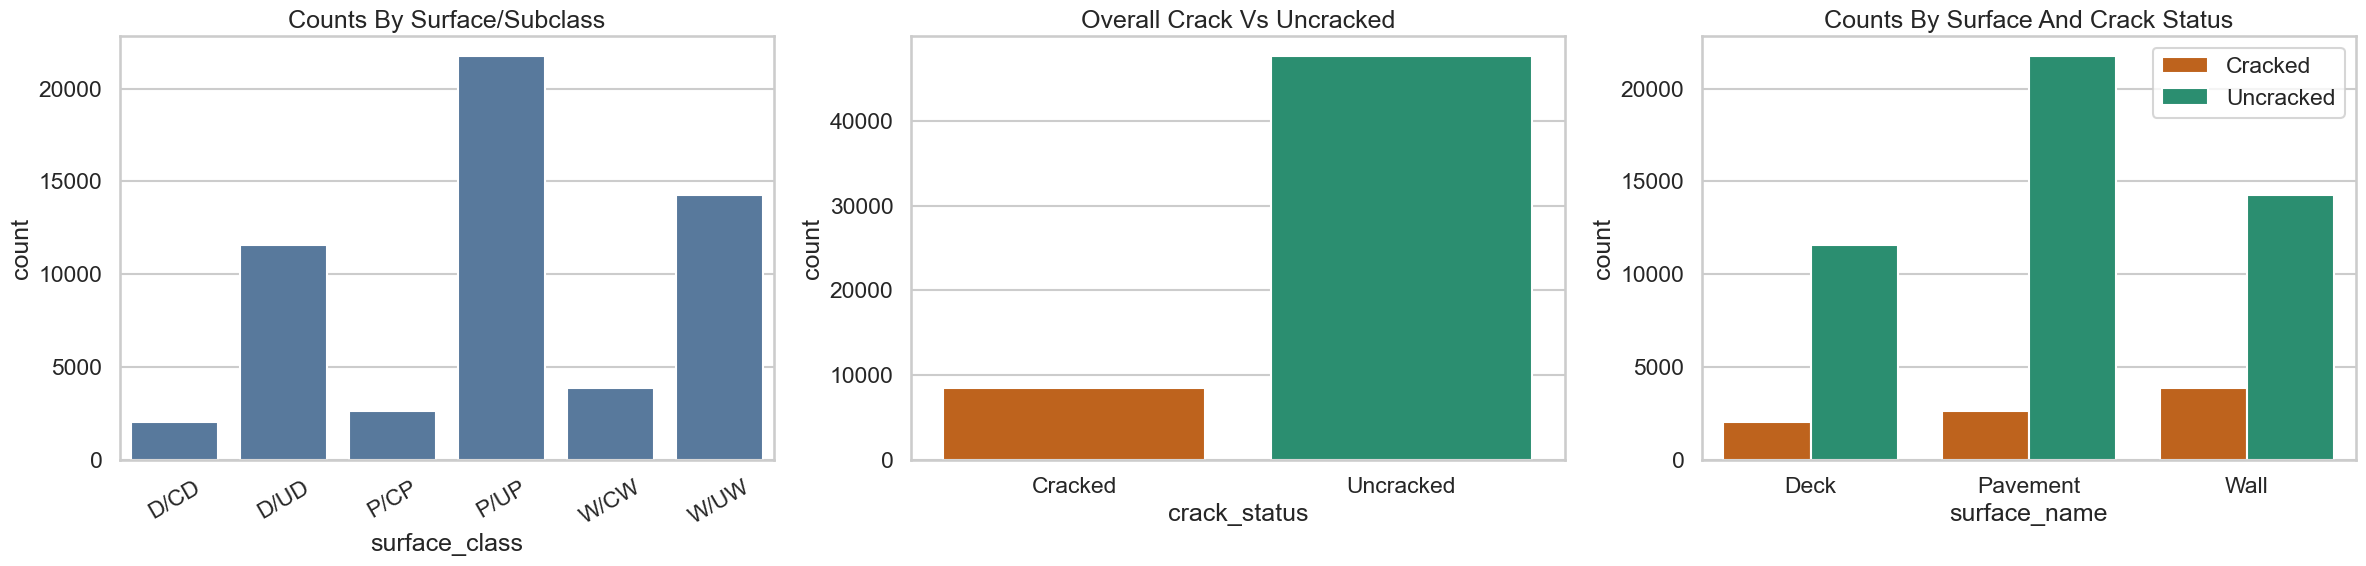

In [5]:
class_counts = (
    manifest_df["surface_class"]
    .value_counts()
    .sort_index()
    .rename_axis("surface_class")
    .reset_index(name="count")
)

crack_counts = (
    manifest_df["crack_status"]
    .value_counts()
    .reindex(["Cracked", "Uncracked"])
    .rename_axis("crack_status")
    .reset_index(name="count")
)

surface_crack_counts = (
    manifest_df.groupby(["surface_name", "crack_status"])
    .size()
    .reset_index(name="count")
)

imbalance_ratio = class_counts["count"].max() / class_counts["count"].min()
print(f"Max/min imbalance across the six SDNET2018 folders: {imbalance_ratio:.2f}x")

fig, axes = plt.subplots(1, 3, figsize=(24, 6))

sns.barplot(data=class_counts, x="surface_class", y="count", ax=axes[0], color="#4c78a8")
axes[0].set_title("Counts By Surface/Subclass")
axes[0].tick_params(axis="x", rotation=30)

sns.barplot(
    data=crack_counts,
    x="crack_status",
    y="count",
    hue="crack_status",
    palette=CRACK_COLORS,
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Overall Crack Vs Uncracked")

sns.barplot(
    data=surface_crack_counts,
    x="surface_name",
    y="count",
    hue="crack_status",
    palette=CRACK_COLORS,
    ax=axes[2],
)
axes[2].set_title("Counts By Surface And Crack Status")
axes[2].legend(title="")

plt.tight_layout()

balance_plot_path = PLOT_DIR / "sdnet2018_class_balance.png"
fig.savefig(balance_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved class balance plot to {balance_plot_path}")

display(class_counts)


## Surface-Wise Crack Rate

Counts are useful, but crack percentages make it easier to see whether deck, pavement, and wall images have different label distributions.


,surface_name,Cracked,Uncracked,total_images,cracked_pct
0,Deck,2025,11595,13620,14.87
1,Pavement,2608,21726,24334,10.72
2,Wall,3851,14287,18138,21.23
3,Overall,8484,47608,56092,15.13


Saved surface crack-rate plot to artifacts\plots\sdnet2018_surface_crack_rate.png


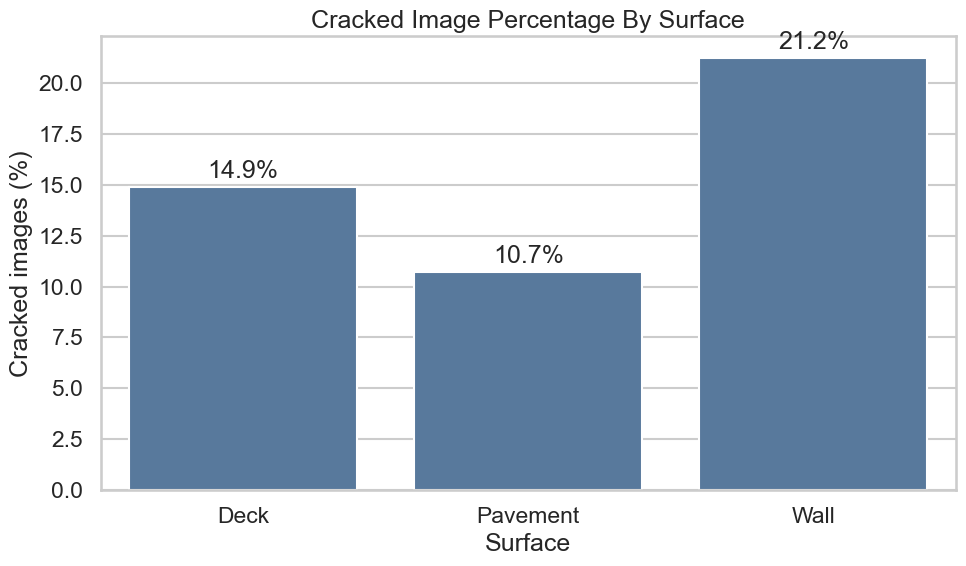

In [6]:
surface_crack_rate_df = (
    manifest_df.pivot_table(
        index="surface_name",
        columns="crack_status",
        values="path",
        aggfunc="count",
        fill_value=0,
    )
    .rename_axis(None, axis=1)
    .reset_index()
)

surface_crack_rate_df["total_images"] = surface_crack_rate_df[["Cracked", "Uncracked"]].sum(axis=1)
surface_crack_rate_df["cracked_pct"] = (
    surface_crack_rate_df["Cracked"] / surface_crack_rate_df["total_images"] * 100
).round(2)

overall_crack_rate_df = pd.DataFrame(
    [
        {
            "surface_name": "Overall",
            "Cracked": int((manifest_df["crack_status"] == "Cracked").sum()),
            "Uncracked": int((manifest_df["crack_status"] == "Uncracked").sum()),
            "total_images": len(manifest_df),
            "cracked_pct": round(float((manifest_df["crack_status"] == "Cracked").mean() * 100), 2),
        }
    ]
)

surface_crack_rate_with_overall_df = pd.concat(
    [surface_crack_rate_df, overall_crack_rate_df],
    ignore_index=True,
)

display(surface_crack_rate_with_overall_df)

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=surface_crack_rate_df,
    x="surface_name",
    y="cracked_pct",
    ax=ax,
    color="#4c78a8",
)
ax.set_title("Cracked Image Percentage By Surface")
ax.set_xlabel("Surface")
ax.set_ylabel("Cracked images (%)")
ax.bar_label(ax.containers[0], fmt="%.1f%%", padding=3)
plt.tight_layout()

surface_rate_plot_path = PLOT_DIR / "sdnet2018_surface_crack_rate.png"
fig.savefig(surface_rate_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved surface crack-rate plot to {surface_rate_plot_path}")


## Pixel Intensity Exploration

Because these images are grayscale, simple intensity statistics can reveal whether one subgroup is systematically brighter, noisier, or more textured than another.


mean_intensity         std_intensity       
                       mean  median          mean median
crack_status                                            
Cracked              169.28  172.99         13.18   9.39
Uncracked            161.25  164.50         15.49  11.61

Saved pixel statistics plot to artifacts\plots\sdnet2018_pixel_statistics.png


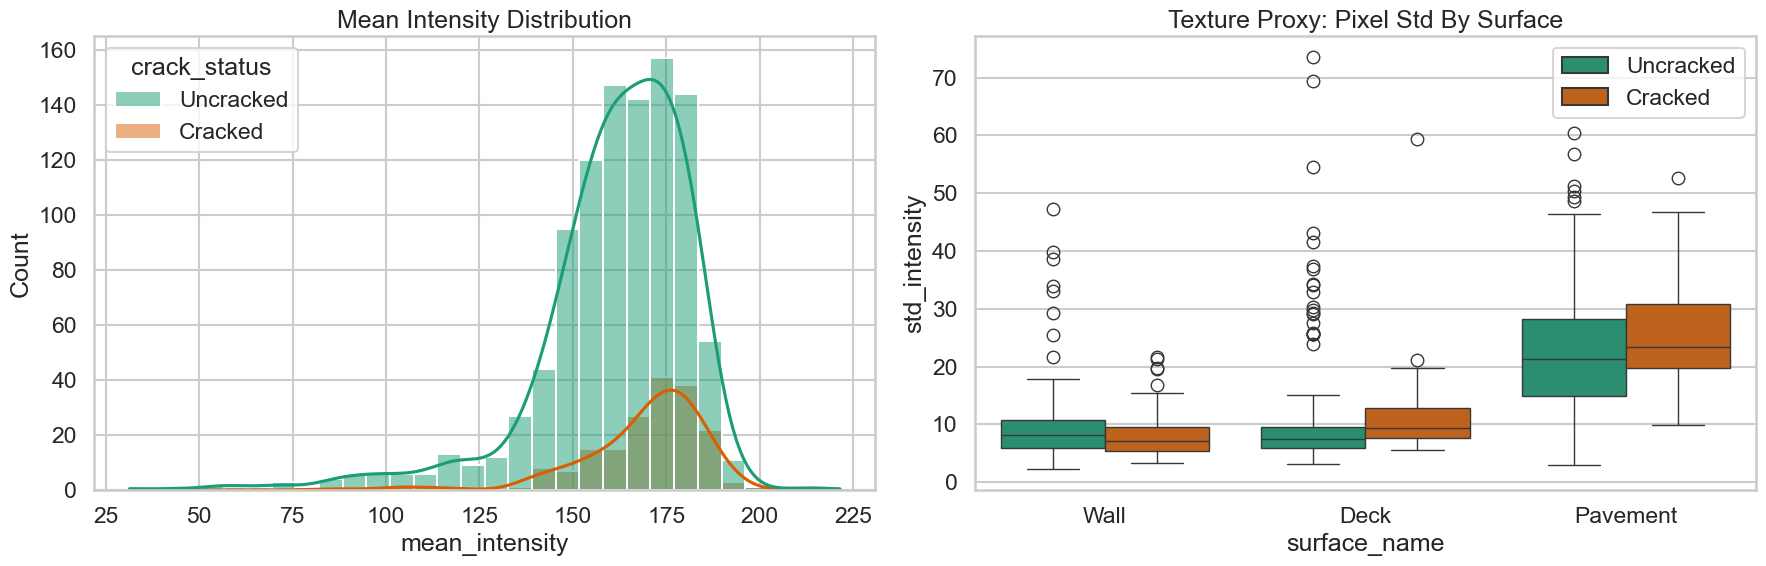

In [7]:
def summarise_pixel_statistics(df: pd.DataFrame, sample_size: int = 1200, seed: int = SEED) -> pd.DataFrame:
    sampled_df = df.sample(n=min(sample_size, len(df)), random_state=seed)
    rows = []

    for row in sampled_df.itertuples(index=False):
        image = load_grayscale(Path(row.path))
        rows.append(
            {
                "surface_name": row.surface_name,
                "crack_status": row.crack_status,
                "mean_intensity": float(image.mean()),
                "std_intensity": float(image.std()),
                "min_intensity": int(image.min()),
                "max_intensity": int(image.max()),
            }
        )

    return pd.DataFrame(rows)


pixel_stats_df = summarise_pixel_statistics(manifest_df)

summary_table = (
    pixel_stats_df.groupby("crack_status")[["mean_intensity", "std_intensity"]]
    .agg(["mean", "median"])
    .round(2)
)
display(summary_table)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

sns.histplot(
    data=pixel_stats_df,
    x="mean_intensity",
    hue="crack_status",
    bins=30,
    kde=True,
    palette=CRACK_COLORS,
    ax=axes[0],
)
axes[0].set_title("Mean Intensity Distribution")

sns.boxplot(
    data=pixel_stats_df,
    x="surface_name",
    y="std_intensity",
    hue="crack_status",
    palette=CRACK_COLORS,
    ax=axes[1],
)
axes[1].set_title("Texture Proxy: Pixel Std By Surface")
axes[1].legend(title="")

plt.tight_layout()

pixel_plot_path = PLOT_DIR / "sdnet2018_pixel_statistics.png"
fig.savefig(pixel_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved pixel statistics plot to {pixel_plot_path}")


## Texture And Edge Density Analysis

Cracks often appear as thin dark edges, so this section adds simple computer-vision features: contrast range, Laplacian variance as a sharpness/texture proxy, and Canny edge density.


contrast_range        laplacian_variance            \
                                    mean median               mean    median   
surface_name crack_status                                                      
Deck         Cracked            148.9000  147.0            68.1350   54.1324   
             Uncracked          122.3734  118.0            62.5400   47.6968   
Pavement     Cracked            207.1190  211.5           542.8438  362.3806   
             Uncracked          185.1591  190.5           495.7453  371.9293   
Wall         Cracked            143.5109  142.0            54.8811   38.9608   
             Uncracked          133.7191  135.0            53.7859   36.4906   

                          edge_density          
                                  mean  median  
surface_name crack_status                       
Deck         Cracked            0.0422  0.0259  
             Uncracked          0.0433  0.0233  
Pavement     Cracked            0.2582  0.2724  
             Uncracked          0.2472  0.2866  
Wall         Cracked            0.0228  0.0099  
             Uncracked          0.0290  0.0143

Saved texture and edge-density plot to artifacts\plots\sdnet2018_texture_edge_features.png


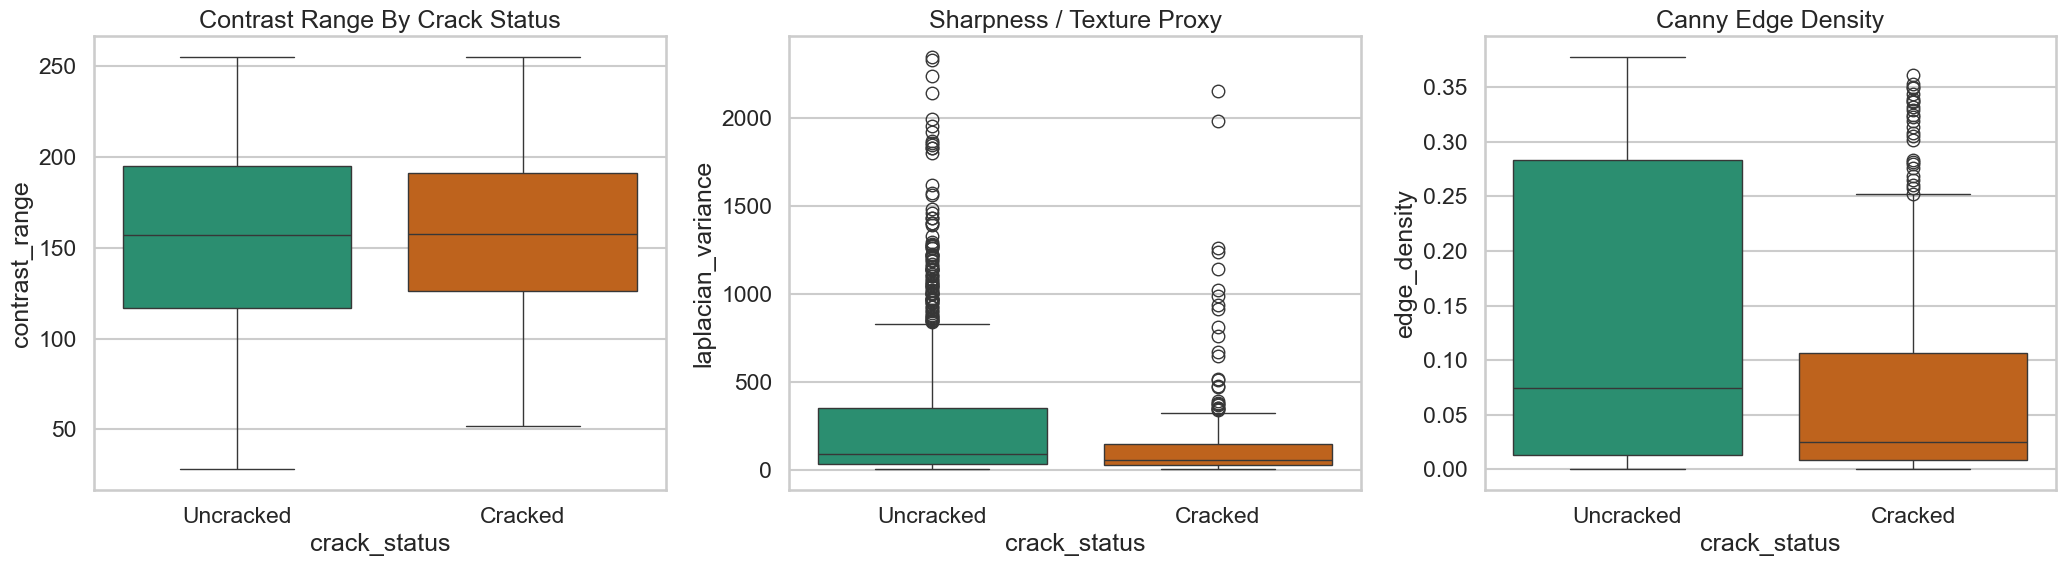

In [8]:
def summarise_texture_edge_features(
    df: pd.DataFrame,
    sample_size: int = 1200,
    seed: int = SEED,
) -> pd.DataFrame:
    sampled_df = df.sample(n=min(sample_size, len(df)), random_state=seed)
    rows = []

    for row in sampled_df.itertuples(index=False):
        image = load_grayscale(Path(row.path))
        edges = cv2.Canny(image, threshold1=50, threshold2=150)

        rows.append(
            {
                "path": row.path,
                "relative_path": row.relative_path,
                "surface_name": row.surface_name,
                "surface_class": row.surface_class,
                "crack_status": row.crack_status,
                "mean_intensity": float(image.mean()),
                "contrast_range": int(image.max()) - int(image.min()),
                "laplacian_variance": float(cv2.Laplacian(image, cv2.CV_64F).var()),
                "edge_density": float((edges > 0).mean()),
            }
        )

    return pd.DataFrame(rows)


texture_edge_df = summarise_texture_edge_features(manifest_df)

texture_edge_summary_df = (
    texture_edge_df.groupby(["surface_name", "crack_status"])[
        ["contrast_range", "laplacian_variance", "edge_density"]
    ]
    .agg(["mean", "median"])
    .round(4)
)
display(texture_edge_summary_df)

fig, axes = plt.subplots(1, 3, figsize=(21, 6))

sns.boxplot(
    data=texture_edge_df,
    x="crack_status",
    y="contrast_range",
    hue="crack_status",
    palette=CRACK_COLORS,
    ax=axes[0],
    legend=False,
)
axes[0].set_title("Contrast Range By Crack Status")

sns.boxplot(
    data=texture_edge_df,
    x="crack_status",
    y="laplacian_variance",
    hue="crack_status",
    palette=CRACK_COLORS,
    ax=axes[1],
    legend=False,
)
axes[1].set_title("Sharpness / Texture Proxy")

sns.boxplot(
    data=texture_edge_df,
    x="crack_status",
    y="edge_density",
    hue="crack_status",
    palette=CRACK_COLORS,
    ax=axes[2],
    legend=False,
)
axes[2].set_title("Canny Edge Density")

plt.tight_layout()

texture_plot_path = PLOT_DIR / "sdnet2018_texture_edge_features.png"
fig.savefig(texture_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved texture and edge-density plot to {texture_plot_path}")


## Representative Samples

A quick image grid helps verify that the cracked and uncracked subfolders actually contain the kinds of visual patterns we expect.


Saved sample grid to artifacts\plots\sdnet2018_sample_grid.png


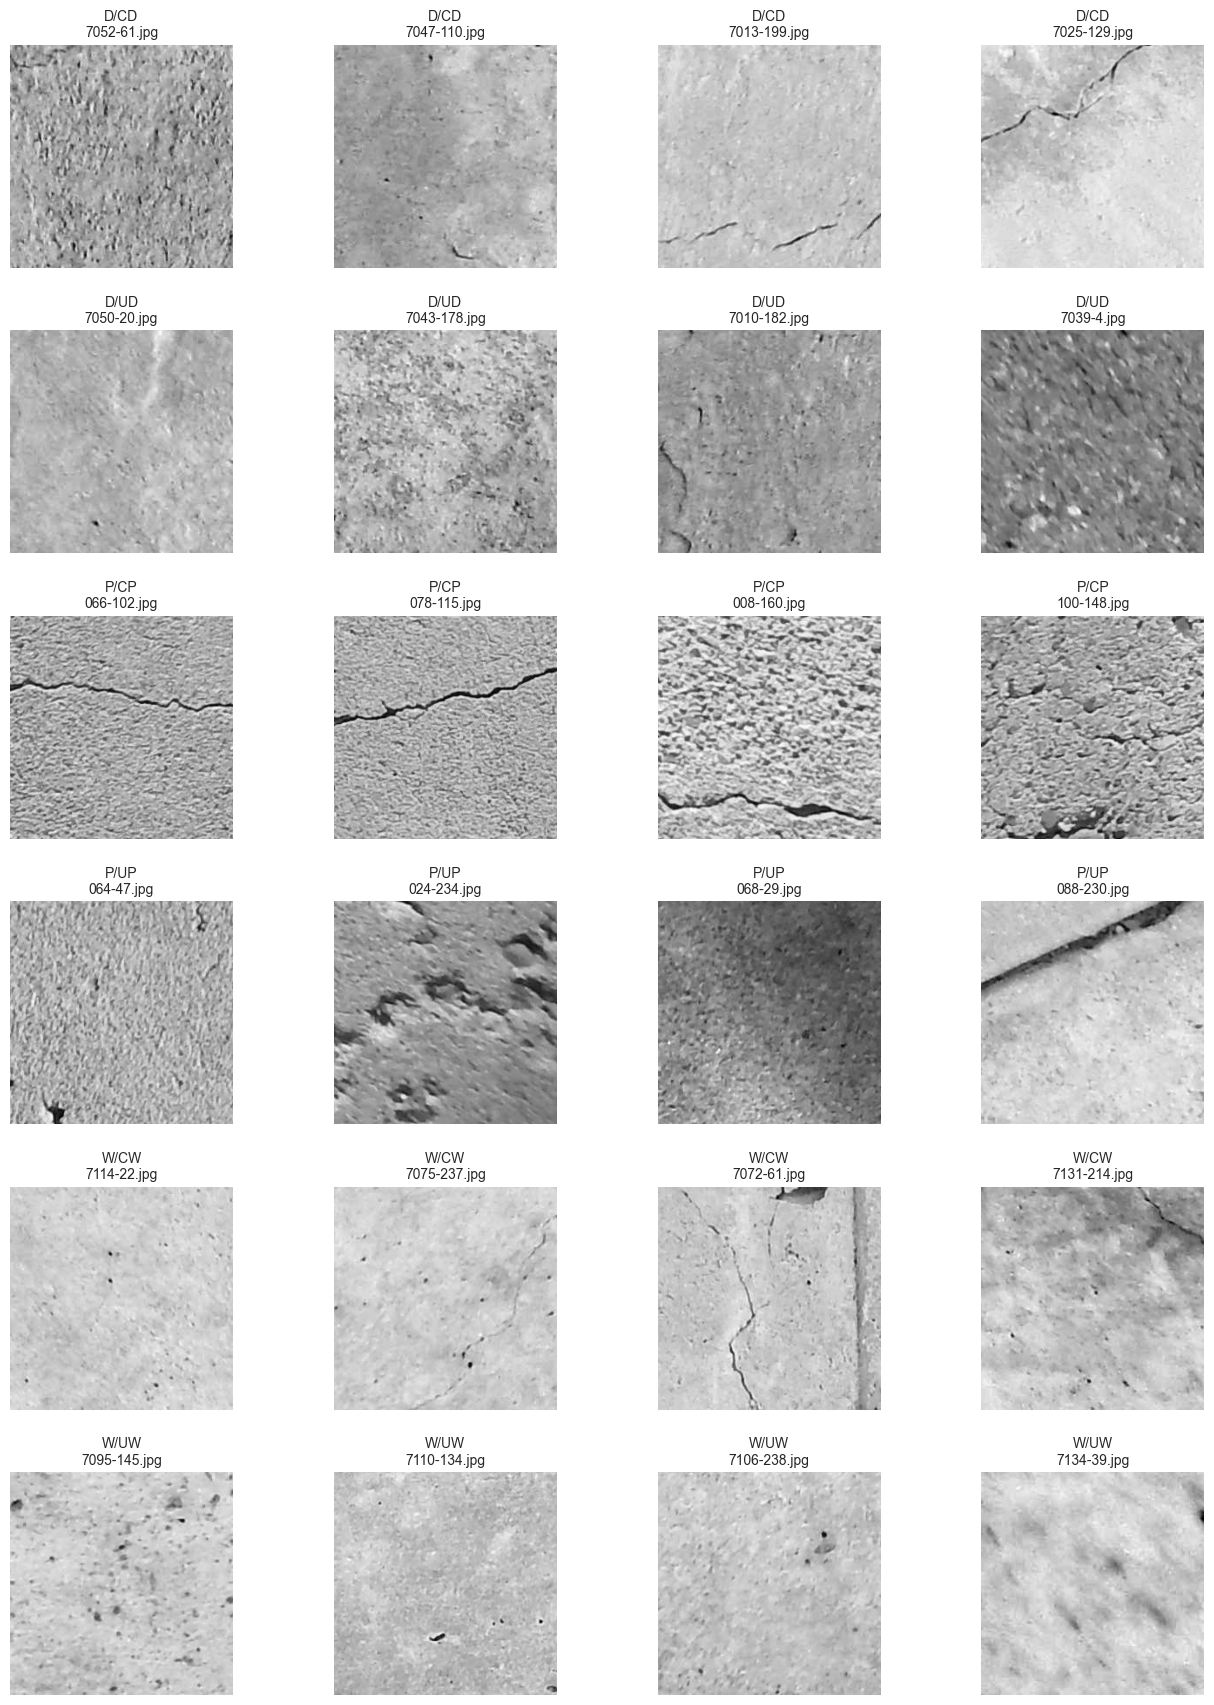

In [9]:
def show_examples_by_group(df: pd.DataFrame, samples_per_group: int = 4, seed: int = SEED) -> None:
    groups = sorted(df["surface_class"].unique())
    fig, axes = plt.subplots(
        len(groups),
        samples_per_group,
        figsize=(3.4 * samples_per_group, 2.9 * len(groups)),
    )

    for row_index, group in enumerate(groups):
        sampled_group = (
            df[df["surface_class"] == group]
            .sample(n=samples_per_group, random_state=seed)
            .reset_index(drop=True)
        )

        for column_index, sample in enumerate(sampled_group.itertuples(index=False)):
            ax = axes[row_index, column_index]
            image = load_grayscale(Path(sample.path))
            ax.imshow(image, cmap="gray")
            ax.set_title(f"{sample.surface_class}\n{Path(sample.relative_path).name}", fontsize=10)
            ax.axis("off")

    plt.tight_layout()

    sample_plot_path = PLOT_DIR / "sdnet2018_sample_grid.png"
    fig.savefig(sample_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved sample grid to {sample_plot_path}")


show_examples_by_group(manifest_df, samples_per_group=4)


## Outlier Image Review

Outlier grids make the data issues visible: very dark images, very bright images, low contrast, high contrast, and high edge-density samples are common sources of model confusion.


,outlier_group,relative_path,surface_class,crack_status,mean_intensity,contrast_range,edge_density
0,Darkest,dataset/D/UD/7016-19.jpg,D/UD,Uncracked,31.4053,202,0.0192
1,Darkest,dataset/D/UD/7029-8.jpg,D/UD,Uncracked,44.1297,222,0.0235
2,Darkest,dataset/P/UP/008-57.jpg,P/UP,Uncracked,55.2401,77,0.0107
3,Darkest,dataset/P/UP/080-162.jpg,P/UP,Uncracked,56.0551,62,0.0000
4,Brightest,dataset/P/CP/001-105.jpg,P/CP,Cracked,221.4239,155,0.3077
5,Brightest,dataset/P/UP/007-126.jpg,P/UP,Uncracked,216.5638,146,0.2900
6,Brightest,dataset/P/UP/055-163.jpg,P/UP,Uncracked,210.1276,233,0.2563
7,Brightest,dataset/P/CP/027-79_2.jpg,P/CP,Cracked,196.2704,239,0.3371
8,Lowest contrast,dataset/W/UW/7123-245.jpg,W/UW,Uncracked,173.9599,28,0.0000
9,Lowest contrast,dataset/D/UD/7034-1.jpg,D/UD,Uncracked,182.7468,31,0.0000


Saved outlier review grid to artifacts\plots\sdnet2018_outlier_review.png


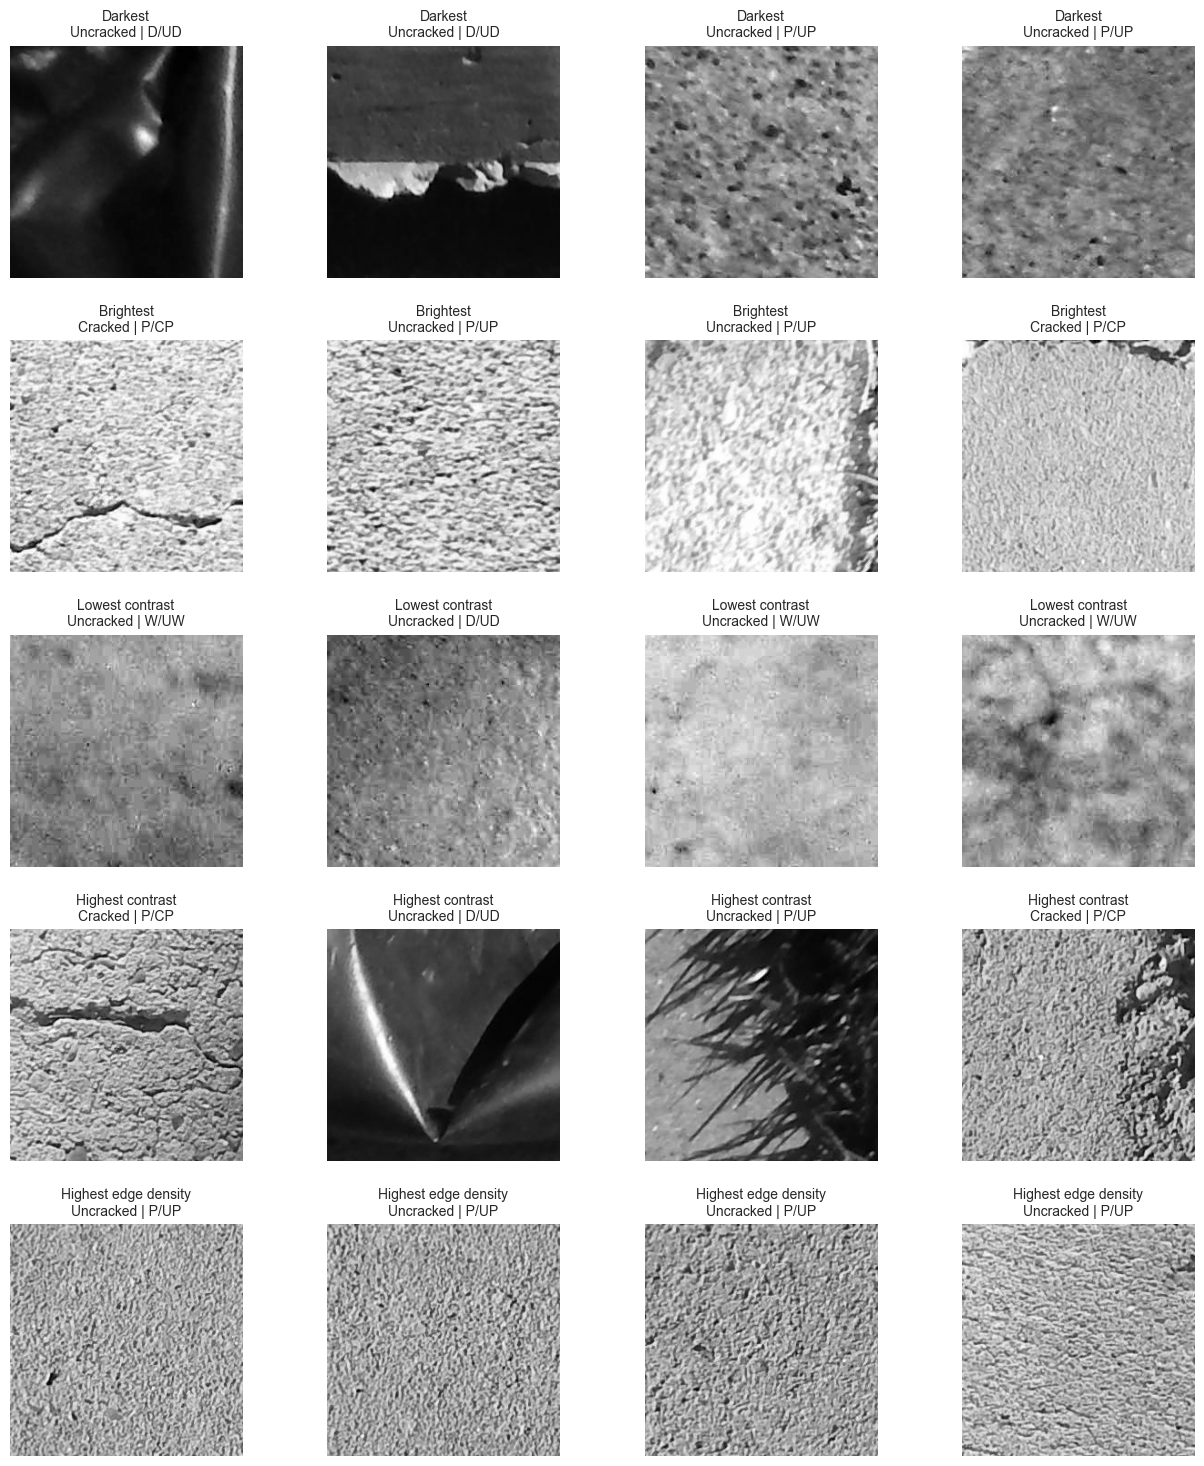

In [10]:
def select_outlier_examples(feature_df: pd.DataFrame, n_examples: int = 4) -> dict[str, pd.DataFrame]:
    return {
        "Darkest": feature_df.nsmallest(n_examples, "mean_intensity"),
        "Brightest": feature_df.nlargest(n_examples, "mean_intensity"),
        "Lowest contrast": feature_df.nsmallest(n_examples, "contrast_range"),
        "Highest contrast": feature_df.nlargest(n_examples, "contrast_range"),
        "Highest edge density": feature_df.nlargest(n_examples, "edge_density"),
    }


def show_outlier_examples(feature_df: pd.DataFrame, n_examples: int = 4) -> None:
    outlier_groups = select_outlier_examples(feature_df, n_examples=n_examples)
    fig, axes = plt.subplots(
        len(outlier_groups),
        n_examples,
        figsize=(3.3 * n_examples, 3.0 * len(outlier_groups)),
    )

    for row_index, (group_name, group_df) in enumerate(outlier_groups.items()):
        for column_index, sample in enumerate(group_df.itertuples(index=False)):
            ax = axes[row_index, column_index]
            image = load_grayscale(Path(sample.path))
            ax.imshow(image, cmap="gray")
            ax.set_title(
                f"{group_name}\n{sample.crack_status} | {sample.surface_class}",
                fontsize=10,
            )
            ax.axis("off")

    plt.tight_layout()

    outlier_plot_path = PLOT_DIR / "sdnet2018_outlier_review.png"
    fig.savefig(outlier_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved outlier review grid to {outlier_plot_path}")


outlier_summary_df = pd.concat(
    [group.assign(outlier_group=name) for name, group in select_outlier_examples(texture_edge_df).items()],
    ignore_index=True,
)

display(
    outlier_summary_df[
        [
            "outlier_group",
            "relative_path",
            "surface_class",
            "crack_status",
            "mean_intensity",
            "contrast_range",
            "edge_density",
        ]
    ].round(4)
)
show_outlier_examples(texture_edge_df, n_examples=4)


## Stratified Train, Validation, And Test Split

The split below preserves the six SDNET2018 subclass proportions so the evaluation sets stay representative.


In [11]:
def stratified_train_val_test_split(
    df: pd.DataFrame,
    stratify_col: str = "surface_class",
    train_size: float = 0.70,
    val_size: float = 0.15,
    test_size: float = 0.15,
    seed: int = SEED,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    if not np.isclose(train_size + val_size + test_size, 1.0):
        raise ValueError("train_size + val_size + test_size must sum to 1.0")

    train_df, temp_df = train_test_split(
        df,
        train_size=train_size,
        stratify=df[stratify_col],
        random_state=seed,
    )

    relative_test_size = test_size / (val_size + test_size)

    val_df, test_df = train_test_split(
        temp_df,
        test_size=relative_test_size,
        stratify=temp_df[stratify_col],
        random_state=seed,
    )

    return (
        train_df.reset_index(drop=True),
        val_df.reset_index(drop=True),
        test_df.reset_index(drop=True),
    )


train_df, val_df, test_df = stratified_train_val_test_split(manifest_df)

split_manifest_df = pd.concat(
    [
        train_df.assign(split="train"),
        val_df.assign(split="validation"),
        test_df.assign(split="test"),
    ],
    ignore_index=True,
)

split_summary = (
    split_manifest_df.groupby(["split", "surface_class"])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)

display(split_summary)
print(
    f"Train: {len(train_df):,} | Validation: {len(val_df):,} | Test: {len(test_df):,}"
)


surface_class,D/CD,D/UD,P/CP,P/UP,W/CW,W/UW
split,,,,,,
test,304,1740,391,3259,577,2143
train,1417,8116,1826,15208,2696,10001
validation,304,1739,391,3259,578,2143


Train: 39,264 | Validation: 8,414 | Test: 8,414


## Split Validation

The split is checked for class-percentage consistency and path leakage so the validation and test sets remain representative and independent.


In [12]:
split_quality_df = (
    split_manifest_df.groupby("split")
    .agg(
        total_images=("path", "size"),
        cracked_images=("binary_label", "sum"),
        unique_paths=("path", "nunique"),
    )
    .reset_index()
)
split_quality_df["uncracked_images"] = split_quality_df["total_images"] - split_quality_df["cracked_images"]
split_quality_df["cracked_pct"] = (
    split_quality_df["cracked_images"] / split_quality_df["total_images"] * 100
).round(2)
split_quality_df["duplicate_paths_within_split"] = split_quality_df["total_images"] - split_quality_df["unique_paths"]

split_class_counts_df = (
    split_manifest_df.groupby(["split", "surface_class"])
    .size()
    .rename("count")
    .reset_index()
)
split_class_counts_df["percentage"] = (
    split_class_counts_df["count"]
    / split_class_counts_df.groupby("split")["count"].transform("sum")
    * 100
).round(2)

split_class_pct_df = (
    split_class_counts_df.pivot(index="split", columns="surface_class", values="percentage")
    .reset_index()
)

split_path_sets = {
    split_name: set(group["path"].astype(str))
    for split_name, group in split_manifest_df.groupby("split")
}

split_overlap_df = pd.DataFrame(
    [
        {
            "comparison": "train vs validation",
            "overlap_count": len(split_path_sets["train"] & split_path_sets["validation"]),
        },
        {
            "comparison": "train vs test",
            "overlap_count": len(split_path_sets["train"] & split_path_sets["test"]),
        },
        {
            "comparison": "validation vs test",
            "overlap_count": len(split_path_sets["validation"] & split_path_sets["test"]),
        },
    ]
)

display(split_quality_df)
display(split_class_pct_df)
display(split_overlap_df)


,split,total_images,cracked_images,unique_paths,uncracked_images,cracked_pct,duplicate_paths_within_split
0,test,8414,1272,8414,7142,15.12,0
1,train,39264,5939,39264,33325,15.13,0
2,validation,8414,1273,8414,7141,15.13,0


surface_class,split,D/CD,D/UD,P/CP,P/UP,W/CW,W/UW
0,test,3.61,20.68,4.65,38.73,6.86,25.47
1,train,3.61,20.67,4.65,38.73,6.87,25.47
2,validation,3.61,20.67,4.65,38.73,6.87,25.47


,comparison,overlap_count
0,train vs validation,0
1,train vs test,0
2,validation vs test,0


## Balancing Options For The Training Split

A good practice is to balance only the training set while keeping validation and test distributions untouched.

This notebook prepares:

- `balanced_train_downsample_df` to match the smallest training subgroup
- `balanced_train_oversample_df` to match the largest subgroup with replacement
- `binary_balanced_train_df` to balance only cracked vs uncracked labels
- class-weight tables that can be fed into a downstream model


,surface_class,original_train,downsampled_train,oversampled_train
0,D/CD,1417,1417,15208
1,D/UD,8116,1417,15208
2,P/CP,1826,1417,15208
3,P/UP,15208,1417,15208
4,W/CW,2696,1417,15208
5,W/UW,10001,1417,15208


,group,count,weight
0,D/CD,1417,4.6182
1,D/UD,8116,0.8063
2,P/CP,1826,3.5838
3,P/UP,15208,0.4303
4,W/CW,2696,2.4273
5,W/UW,10001,0.6543


,crack_status,original_train,binary_balanced_train
0,Cracked,5939,5939
1,Uncracked,33325,5939


,group,count,weight
0,Cracked,5939,3.3056
1,Uncracked,33325,0.5891


Saved balancing plot to artifacts\plots\sdnet2018_balancing_options.png


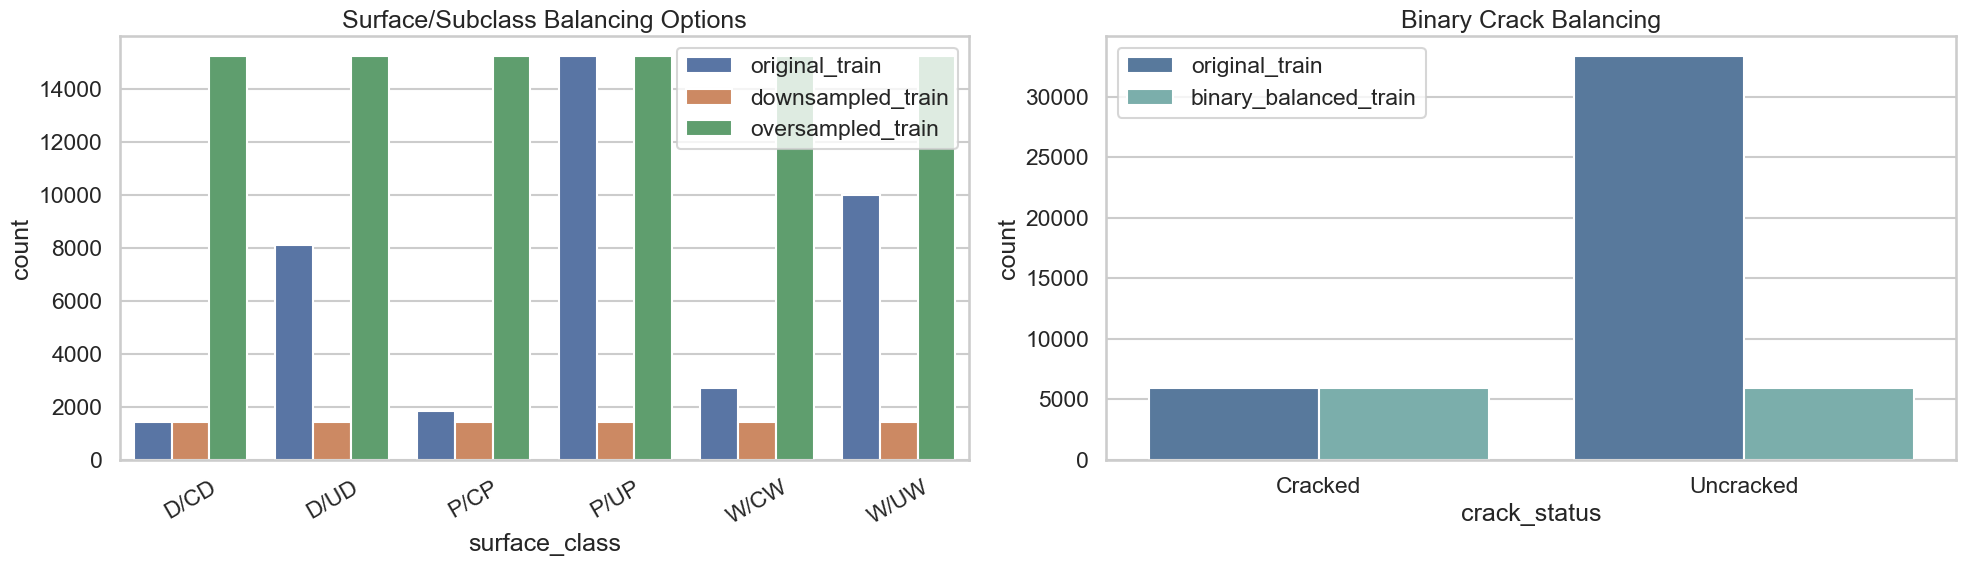

In [13]:
def make_balanced_subset(
    df: pd.DataFrame,
    group_col: str = "surface_class",
    strategy: str = "downsample",
    seed: int = SEED,
) -> pd.DataFrame:
    counts = df[group_col].value_counts().sort_index()

    if strategy == "downsample":
        target_count = int(counts.min())
        replace = False
    elif strategy == "oversample":
        target_count = int(counts.max())
        replace = True
    else:
        raise ValueError("strategy must be either 'downsample' or 'oversample'")

    balanced_frames = []

    for offset, group_name in enumerate(counts.index):
        group_df = df[df[group_col] == group_name]
        balanced_frames.append(
            group_df.sample(
                n=target_count,
                replace=replace,
                random_state=seed + offset,
            )
        )

    balanced_df = pd.concat(balanced_frames, ignore_index=True)
    return balanced_df.sample(frac=1.0, random_state=seed).reset_index(drop=True)


def make_class_weight_table(df: pd.DataFrame, group_col: str) -> pd.DataFrame:
    counts = df[group_col].value_counts().sort_index()
    weights = counts.sum() / (len(counts) * counts)
    return pd.DataFrame(
        {
            "group": counts.index,
            "count": counts.values,
            "weight": weights.round(4).values,
        }
    )


balanced_train_downsample_df = make_balanced_subset(
    train_df,
    group_col="surface_class",
    strategy="downsample",
)

balanced_train_oversample_df = make_balanced_subset(
    train_df,
    group_col="surface_class",
    strategy="oversample",
)

binary_balanced_train_df = make_balanced_subset(
    train_df,
    group_col="crack_status",
    strategy="downsample",
)

multiclass_weight_table = make_class_weight_table(train_df, group_col="surface_class")
binary_weight_table = make_class_weight_table(train_df, group_col="crack_status")

surface_balance_comparison_df = pd.concat(
    [
        train_df["surface_class"].value_counts().sort_index().rename("original_train"),
        balanced_train_downsample_df["surface_class"]
        .value_counts()
        .sort_index()
        .rename("downsampled_train"),
        balanced_train_oversample_df["surface_class"]
        .value_counts()
        .sort_index()
        .rename("oversampled_train"),
    ],
    axis=1,
).reset_index(names="surface_class")

binary_balance_comparison_df = pd.concat(
    [
        train_df["crack_status"].value_counts().sort_index().rename("original_train"),
        binary_balanced_train_df["crack_status"]
        .value_counts()
        .sort_index()
        .rename("binary_balanced_train"),
    ],
    axis=1,
).reset_index(names="crack_status")

display(surface_balance_comparison_df)
display(multiclass_weight_table)
display(binary_balance_comparison_df)
display(binary_weight_table)

fig, axes = plt.subplots(1, 2, figsize=(20, 6))

surface_plot_df = surface_balance_comparison_df.melt(
    id_vars="surface_class",
    var_name="variant",
    value_name="count",
)
sns.barplot(
    data=surface_plot_df,
    x="surface_class",
    y="count",
    hue="variant",
    ax=axes[0],
)
axes[0].set_title("Surface/Subclass Balancing Options")
axes[0].tick_params(axis="x", rotation=30)
axes[0].legend(title="")

binary_plot_df = binary_balance_comparison_df.melt(
    id_vars="crack_status",
    var_name="variant",
    value_name="count",
)
sns.barplot(
    data=binary_plot_df,
    x="crack_status",
    y="count",
    hue="variant",
    palette=["#4c78a8", "#72b7b2"],
    ax=axes[1],
)
axes[1].set_title("Binary Crack Balancing")
axes[1].legend(title="")

plt.tight_layout()

balancing_plot_path = PLOT_DIR / "sdnet2018_balancing_options.png"
fig.savefig(balancing_plot_path, dpi=200, bbox_inches="tight")
print(f"Saved balancing plot to {balancing_plot_path}")


## Export Manifests For Downstream Training

The exported CSV files can be used directly by later classification or segmentation pipelines.


In [14]:
def export_manifest(frame: pd.DataFrame, destination: Path) -> None:
    export_frame = frame.copy()
    export_frame["path"] = export_frame["path"].astype(str)
    export_frame.to_csv(destination, index=False)


export_targets = {
    "sdnet2018_manifest.csv": manifest_df,
    "sdnet2018_split_manifest.csv": split_manifest_df,
    "sdnet2018_train_balanced_downsample.csv": balanced_train_downsample_df,
    "sdnet2018_train_balanced_oversample.csv": balanced_train_oversample_df,
    "sdnet2018_train_binary_balanced.csv": binary_balanced_train_df,
}

export_rows = []

for file_name, frame in export_targets.items():
    destination = MANIFEST_DIR / file_name
    export_manifest(frame, destination)
    export_rows.append({"file": destination.as_posix(), "rows": len(frame)})

export_summary_df = pd.DataFrame(export_rows)
display(export_summary_df)


,file,rows
0,artifacts/manifests/sdnet2018_manifest.csv,56092
1,artifacts/manifests/sdnet2018_split_manifest.csv,56092
2,artifacts/manifests/sdnet2018_train_balanced_d...,8502
3,artifacts/manifests/sdnet2018_train_balanced_o...,91248
4,artifacts/manifests/sdnet2018_train_binary_bal...,11878


## MLflow Dataset Tracking

This cell records the dataset profile, quality checks, split statistics, exported manifests, and any plots already saved under `artifacts/plots` in MLflow. By default it writes to `artifacts/mlruns`; set `MLFLOW_TRACKING_URI` to use a shared tracking server. Rerun this cell after later visualisation cells if you want those plots included in a tracked run.


In [15]:
def track_dataset_with_mlflow() -> None:
    if importlib.util.find_spec("mlflow") is None:
        print(
            "MLflow is not installed. Install it with `uv add mlflow` or `pip install mlflow`, then rerun this cell to track the dataset."
        )
        return

    import mlflow

    tracking_uri = os.getenv("MLFLOW_TRACKING_URI", MLFLOW_TRACKING_DIR.resolve().as_uri())
    mlflow.set_tracking_uri(tracking_uri)
    mlflow.set_experiment(os.getenv("MLFLOW_EXPERIMENT_NAME", "project_6a_crack_detection_data_exploration"))

    dataset_profile_df = manifest_df[
        [
            "relative_path",
            "surface_name",
            "surface_class",
            "crack_status",
            "binary_label",
            "height",
            "width",
            "file_sha256",
        ]
    ].copy()

    with mlflow.start_run(run_name="sdnet2018_dataset_exploration") as run:
        mlflow.set_tag("project", "Project 6a: Crack Detection")
        mlflow.set_tag("stage", "data_exploration")
        mlflow.set_tag("dataset", "SDNET2018")
        mlflow.set_tag("dataset_api_version", DATASET_API_VERSION)

        mlflow.log_param("dataset_root", str(DATASET_ROOT.resolve()))
        mlflow.log_param("dataset_api_configured", bool(DATASET_API_URL))
        mlflow.log_param("manifest_rows", len(manifest_df))
        mlflow.log_param("surface_types", manifest_df["surface_name"].nunique())
        mlflow.log_param("surface_subclasses", manifest_df["surface_class"].nunique())

        mlflow.log_metrics(
            {
                "total_images": float(len(manifest_df)),
                "cracked_images": float((manifest_df["crack_status"] == "Cracked").sum()),
                "uncracked_images": float((manifest_df["crack_status"] == "Uncracked").sum()),
                "crack_ratio": float(manifest_df["binary_label"].mean()),
                "missing_files": float((~quality_audit_df["exists"]).sum()),
                "unreadable_images": float((~quality_audit_df["readable"]).sum()),
                "duplicate_hash_groups": float(len(duplicate_hash_df)),
                "train_images": float(len(train_df)),
                "validation_images": float(len(val_df)),
                "test_images": float(len(test_df)),
            }
        )

        try:
            mlflow_dataset = mlflow.data.from_pandas(
                dataset_profile_df,
                name="sdnet2018_manifest",
                targets="binary_label",
            )
            mlflow.log_input(mlflow_dataset, context="data_exploration")
        except Exception as exc:
            print(f"MLflow dataset input logging was skipped: {exc}")

        for artifact_path in export_summary_df["file"]:
            path = Path(artifact_path)
            if path.exists():
                mlflow.log_artifact(str(path), artifact_path="manifests")

        for plot_path in sorted(PLOT_DIR.glob("sdnet2018_*.png")):
            mlflow.log_artifact(str(plot_path), artifact_path="plots")

        print(f"Tracked SDNET2018 dataset exploration in MLflow run: {run.info.run_id}")
        print(f"MLflow tracking URI: {tracking_uri}")


track_dataset_with_mlflow()


MLflow is not installed. Install it with `uv add mlflow` or `pip install mlflow`, then rerun this cell to track the dataset.


## Image Transformation Pipeline

These augmentations are mild enough to preserve crack structure while still improving robustness to viewpoint, illumination, and sensor variation.


In [16]:
def build_transforms(image_size: int = 224) -> tuple[A.Compose, A.Compose]:
    train_transform = A.Compose(
        [
            A.Resize(image_size, image_size),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.RandomRotate90(p=0.5),
            A.Affine(
                scale=(0.95, 1.05),
                translate_percent=(-0.04, 0.04),
                rotate=(-12, 12),
                shear=(-4, 4),
                interpolation=cv2.INTER_LINEAR,
                border_mode=cv2.BORDER_REFLECT_101,
                p=0.6,
            ),
            A.OneOf(
                [
                    A.CLAHE(clip_limit=(2.0, 4.0), tile_grid_size=(8, 8), p=1.0),
                    A.RandomBrightnessContrast(
                        brightness_limit=0.15,
                        contrast_limit=0.15,
                        brightness_by_max=True,
                        p=1.0,
                    ),
                    A.Sharpen(alpha=(0.1, 0.3), lightness=(0.9, 1.1), p=1.0),
                ],
                p=0.45,
            ),
            A.OneOf(
                [
                    A.GaussianBlur(blur_limit=(3, 5), sigma_limit=(0.5, 1.5), p=1.0),
                    A.MotionBlur(blur_limit=(3, 5), p=1.0),
                    A.GaussNoise(std_range=(0.02, 0.06), per_channel=False, p=1.0),
                ],
                p=0.25,
            ),
        ]
    )

    eval_transform = A.Compose([A.Resize(image_size, image_size)])
    return train_transform, eval_transform


train_transform, eval_transform = build_transforms(image_size=224)
train_transform


Compose([
  Resize(p=1.0, area_for_downscale=None, height=224, interpolation=1, mask_interpolation=0, width=224),
  HorizontalFlip(p=0.5),
  VerticalFlip(p=0.2),
  RandomRotate90(p=0.5),
  Affine(p=0.6, balanced_scale=False, border_mode=4, fill=0.0, fill_mask=0.0, fit_output=False, interpolation=1, keep_ratio=False, mask_interpolation=0, rotate=(-12.0, 12.0), rotate_method='largest_box', scale={'x': (0.95, 1.05), 'y': (0.95, 1.05)}, shear={'x': (-4.0, 4.0), 'y': (-4.0, 4.0)}, translate_percent={'x': (-0.04, 0.04), 'y': (-0.04, 0.04)}, translate_px=None),
  OneOf([
    CLAHE(p=1.0, clip_limit=(2.0, 4.0), tile_grid_size=(8, 8)),
    RandomBrightnessContrast(p=1.0, brightness_by_max=True, brightness_limit=(-0.15, 0.15), contrast_limit=(-0.15, 0.15), ensure_safe_range=False),
    Sharpen(p=1.0, alpha=(0.1, 0.3), kernel_size=5, lightness=(0.9, 1.1), method='kernel', sigma=1.0),
  ], p=0.45),
  OneOf([
    GaussianBlur(p=1.0, blur_limit=(3, 5), sigma_limit=(0.5, 1.5)),
    MotionBlur(p=1.0, 

## Augmentation Preview

Running the transformation pipeline on one cracked and one uncracked example is a quick way to verify that the augmentations are realistic rather than destructive.


Saved augmentation preview to artifacts\plots\sdnet2018_augmentation_preview.png


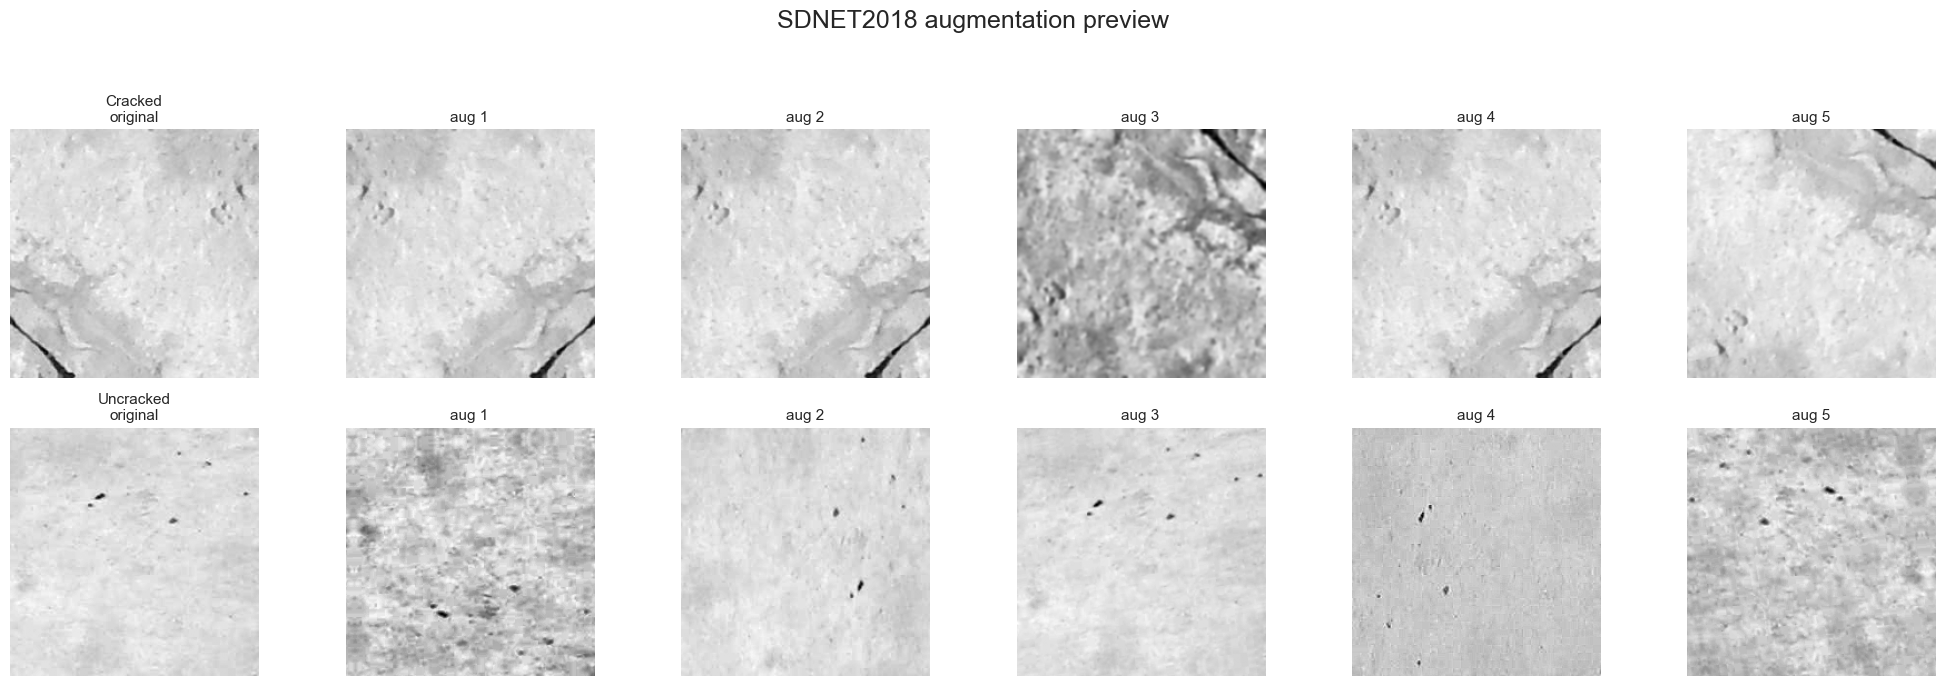

In [17]:
def preview_augmentation_rows(
    df: pd.DataFrame,
    transform: A.Compose,
    crack_statuses: tuple[str, ...] = ("Cracked", "Uncracked"),
    n_variants: int = 5,
    seed: int = SEED,
) -> None:
    fig, axes = plt.subplots(
        len(crack_statuses),
        n_variants + 1,
        figsize=(3.4 * (n_variants + 1), 3.4 * len(crack_statuses)),
    )

    if len(crack_statuses) == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_index, crack_status in enumerate(crack_statuses):
        sample_row = (
            df[df["crack_status"] == crack_status]
            .sample(n=1, random_state=seed + row_index)
            .iloc[0]
        )

        image = load_grayscale(Path(sample_row.path))
        variants = [image] + [transform(image=image)["image"] for _ in range(n_variants)]

        for column_index, variant in enumerate(variants):
            ax = axes[row_index, column_index]
            ax.imshow(variant, cmap="gray")

            if column_index == 0:
                ax.set_title(f"{crack_status}\noriginal", fontsize=11)
            else:
                ax.set_title(f"aug {column_index}", fontsize=11)

            ax.axis("off")

    fig.suptitle("SDNET2018 augmentation preview", y=1.02, fontsize=18)
    plt.tight_layout()

    preview_plot_path = PLOT_DIR / "sdnet2018_augmentation_preview.png"
    fig.savefig(preview_plot_path, dpi=200, bbox_inches="tight")
    print(f"Saved augmentation preview to {preview_plot_path}")


preview_augmentation_rows(manifest_df, train_transform, n_variants=5)


## Key Findings

- SDNET2018 is strongly imbalanced toward uncracked images, so class balance must be handled during training.
- Crack prevalence differs by surface type, which supports stratifying splits by the six original surface/subclass folders.
- The quality audit records missing files, unreadable images, duplicate path rows, repeated filenames, exact duplicate file hashes, and observed image shapes before modelling.
- Split validation checks that train, validation, and test sets preserve subclass percentages and do not leak image paths across splits.
- Texture, edge-density, and outlier reviews add visual evidence about shadows, contrast, blur, and highly textured images that may influence model performance.
- Balanced training manifests are prepared while validation and test distributions remain untouched for honest evaluation.
- MLflow tracking captures dataset metadata, quality metrics, split sizes, exported manifests, and available plots for reproducibility.


## References

- Dorafshan, S., Thomas, R. J., & Maguire, M. (2018). SDNET2018: An annotated image dataset for non-contact concrete crack detection using deep convolutional neural networks. *Data in Brief, 21*, 1664-1668. https://doi.org/10.1016/j.dib.2018.11.015
- Maguire, M., Dorafshan, S., & Thomas, R. J. (2018). SDNET2018: A concrete crack image dataset for machine learning applications. Utah State University. https://doi.org/10.15142/T3TD19
- Buslaev, A., Parinov, A., Khvedchenya, E., Iglovikov, V. I., & Kalinin, A. A. (2018). Albumentations: fast and flexible image augmentations. arXiv:1809.06839. https://arxiv.org/abs/1809.06839
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, E. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825-2830. https://www.jmlr.org/papers/v12/pedregosa11a.html
- MLflow. (n.d.). MLflow Tracking. https://mlflow.org/docs/latest/tracking/
- Bradski, G. (2000). The OpenCV Library. *Dr. Dobb's Journal of Software Tools*. https://opencv.org/
